# MedQuAD — Analyse Exploratoire (EDA)

## Synthèse & Observations

### Structure du dataset
- **Langue :** Anglais | **Source :** sources médicales institutionnelles américaines (NIH, NCI...) (`keivalya/MedQuad` sur HuggingFace)
- Format QA direct (question ouverte → réponse textuelle détaillée), pas de QCM
- 1 seul split : `train` (16 407 lignes)
- Colonnes : `qtype` (type de question, 16 catégories), `Question`, `Answer`
- Plus grande source de données QA directe du corpus — **nettoyage minimal requis**

### Points d'attention
- ~80 doublons exacts détectés (questions/réponses identiques)
- `qtype` : 16 catégories (information, symptoms, causes, treatment, exams and tests...) → métadonnée non pertinente pour le SFT
- Colonnes nommées `Question` / `Answer` (majuscules) → à renommer pour uniformiser avec le schéma commun
- Réponses longues, structurées, multi-paragraphes → bon signal d'apprentissage pour la génération de réponses médicales complètes
- Pas de QCM, pas de cas clinique, pas de propositions numérotées → pas de filtrage sémantique nécessaire
- Aucune valeur manquante

### Décisions de nettoyage → `src/processing/medquad_cleaning.py`
- Supprimer les doublons
- Supprimer la colonne `qtype`
- Renommer `Question → question`, `Answer → answer`
- Normaliser en minuscules | Ajouter `dataset_name = "medquad"`

---
## 1. Chargement des données

In [1]:
from datasets import load_from_disk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Fabien\Desktop\OC\P14\FINE-TUNING_MEDICAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
medquad_dataset = load_from_disk("gs://p14-medical-data/raw_data/MedQuad_dataset/")
print(medquad_dataset)

DatasetDict({
    train: Dataset({
        features: ['qtype', 'Question', 'Answer'],
        num_rows: 16407
    })
})


---
## 2. Exploration de la structure

In [3]:
df = pd.DataFrame(medquad_dataset["train"])
print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
df.head(5)

Shape : (16407, 3)
Colonnes : ['qtype', 'Question', 'Answer']


,qtype,Question,Answer
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos..."
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen..."


In [4]:
df.describe()

,qtype,Question,Answer
count,16407,16407,16407
unique,16,14979,15817
top,information,What causes Causes of Diabetes ?,This condition is inherited in an autosomal re...
freq,4535,20,348


In [5]:
df.isna().sum()

qtype       0
Question    0
Answer      0
dtype: int64

---
## 3. Distribution des variables clés

In [6]:
# Distribution des types de questions (qtype)
df["qtype"].value_counts()

qtype
information        4535
symptoms           2748
treatment          2442
inheritance        1446
frequency          1120
genetic changes    1087
causes              727
exams and tests     653
research            395
outlook             361
susceptibility      324
considerations      235
prevention          210
stages               77
complications        46
support groups        1
Name: count, dtype: int64

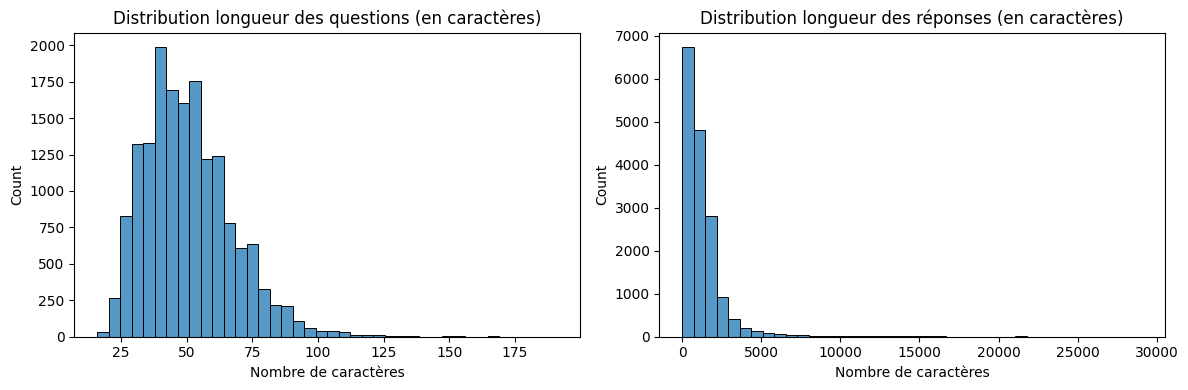

In [7]:
# Distribution des longueurs de réponses
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Question"].str.len(), bins=40, ax=axes[0])
axes[0].set_title("Distribution longueur des questions (en caractères)")
axes[0].set_xlabel("Nombre de caractères")

sns.histplot(df["Answer"].str.len(), bins=40, ax=axes[1])
axes[1].set_title("Distribution longueur des réponses (en caractères)")
axes[1].set_xlabel("Nombre de caractères")

plt.tight_layout()
plt.show()

---
## 4. Analyse des doublons

In [8]:
print(f"Doublons exacts : {df.duplicated().sum()}")
df[df.duplicated(keep=False)].head(10)

Doublons exacts : 48


,qtype,Question,Answer
1387,information,What is (are) Hypoglycemia ?,"Hypoglycemia, also called low blood glucose or..."
1388,information,What is (are) Hypoglycemia ?,"Hypoglycemia, also called low blood glucose or..."
1389,symptoms,What are the symptoms of Hypoglycemia ?,Hypoglycemia causes symptoms such as\n ...
1390,symptoms,What are the symptoms of Hypoglycemia ?,Hypoglycemia causes symptoms such as\n ...
1391,causes,What causes Hypoglycemia ?,Diabetes Medications\n \nHypogl...
1392,causes,What causes Hypoglycemia ?,Diabetes Medications\n \nHypogl...
1394,treatment,What are the treatments for Hypoglycemia ?,Signs and symptoms of hypoglycemia vary from p...
1395,treatment,What are the treatments for Hypoglycemia ?,Signs and symptoms of hypoglycemia vary from p...
1595,treatment,What are the treatments for Acromegaly ?,"Currently, treatment options include surgical ..."
1596,treatment,What are the treatments for Acromegaly ?,"Currently, treatment options include surgical ..."


In [9]:
# Doublons sur la question uniquement
print(f"Doublons sur la Question : {df.duplicated(subset=['Question']).sum()}")
df[df.duplicated(subset=['Question'], keep=False)][["Question", "qtype"]].head(10)

Doublons sur la Question : 1428


,Question,qtype
0,Who is at risk for Lymphocytic Choriomeningiti...,susceptibility
2,Who is at risk for Lymphocytic Choriomeningiti...,susceptibility
55,Who is at risk for Alkhurma Hemorrhagic Fever ...,susceptibility
57,Who is at risk for Alkhurma Hemorrhagic Fever ...,susceptibility
87,Who is at risk for Marburg hemorrhagic fever (...,susceptibility
89,Who is at risk for Marburg hemorrhagic fever (...,susceptibility
113,Who is at risk for Nocardiosis? ?,susceptibility
114,Who is at risk for Nocardiosis? ?,susceptibility
117,Who is at risk for Chapare Hemorrhagic Fever (...,susceptibility
119,Who is at risk for Chapare Hemorrhagic Fever (...,susceptibility


---
## 5. Exemples de paires Question/Answer

In [10]:
pd.set_option('display.max_colwidth', None)
# Exemples par type de question
for qtype in df["qtype"].value_counts().head(5).index:
    sample = df[df["qtype"] == qtype].iloc[0]
    print(f"=== qtype: {qtype} ===")
    print(f"Q: {sample['Question'][:200]}")
    print(f"A: {sample['Answer'][:300]}")
    print()

=== qtype: information ===
Q: What is (are) Parasites - Cysticercosis ?
A: Cysticercosis is an infection caused by the larvae of the parasite Taenia solium.  This infection occurs after a person swallows tapeworm eggs. The larvae get into tissues such as muscle and brain, and form cysts there (these are called cysticerci). When cysts are found in the brain, the condition i

=== qtype: symptoms ===
Q: What are the symptoms of Lymphocytic Choriomeningitis (LCM) ?
A: LCMV is most commonly recognized as causing neurological disease, as its name implies, though infection without symptoms or mild febrile illnesses are more common clinical manifestations. 
                
For infected persons who do become ill, onset of symptoms usually occurs 8-13 days after expos

=== qtype: treatment ===
Q: What are the treatments for Lymphocytic Choriomeningitis (LCM) ?
A: Aseptic meningitis, encephalitis, or meningoencephalitis requires hospitalization and supportive treatment based on severity. Anti-in